In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
df.dropna(axis = 0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Location'] = encoder.fit_transform(df['Location'])

In [7]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,2,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,2,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,2,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,2,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [8]:
df['RainToday'] = np.where(df['RainToday'].astype(str).str.contains('No'),0,1)
df['RainTomorrow'] = np.where(df['RainTomorrow'].astype(str).str.contains('No'),0,1)

In [9]:
df['RainTomorrow'].value_counts()

RainTomorrow
0    110316
1     35144
Name: count, dtype: int64

In [10]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,2,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0
1,2008-12-02,2,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0
2,2008-12-03,2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0
3,2008-12-04,2,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0
4,2008-12-05,2,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0


In [11]:
df['RainToday'].value_counts()

RainToday
0    110319
1     35141
Name: count, dtype: int64

<Axes: >

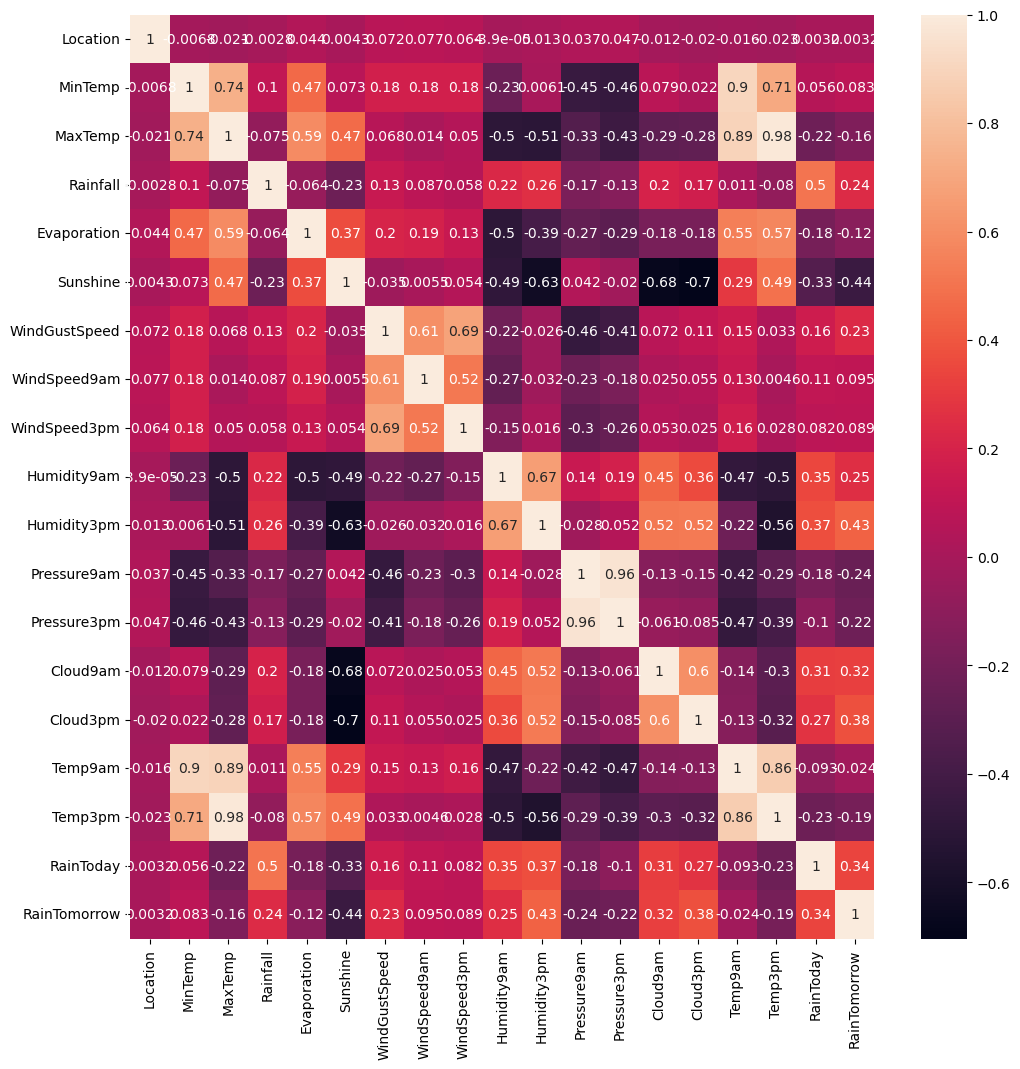

In [12]:
plt.figure(figsize = (12,12))
sns.heatmap(df.corr(numeric_only = True),annot = True)

In [13]:
df.drop(['Sunshine' , 'Evaporation' ], axis = 1 , inplace = True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  int64         
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   WindGustDir    135134 non-null  object        
 6   WindGustSpeed  135197 non-null  float64       
 7   WindDir9am     134894 non-null  object        
 8   WindDir3pm     141232 non-null  object        
 9   WindSpeed9am   143693 non-null  float64       
 10  WindSpeed3pm   142398 non-null  float64       
 11  Humidity9am    142806 non-null  float64       
 12  Humidity3pm    140953 non-null  float64       
 13  Pressure9am    130395 non-null  float64       
 14  Pressure3pm    130432 non-null  float64       
 15  

In [15]:
df['Cloud9am'] = df['Cloud9am'].fillna(df['Cloud9am'].median())

In [16]:
df['Cloud3pm'] = df['Cloud3pm'].fillna(df['Cloud3pm'].median())

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  int64         
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   WindGustDir    135134 non-null  object        
 6   WindGustSpeed  135197 non-null  float64       
 7   WindDir9am     134894 non-null  object        
 8   WindDir3pm     141232 non-null  object        
 9   WindSpeed9am   143693 non-null  float64       
 10  WindSpeed3pm   142398 non-null  float64       
 11  Humidity9am    142806 non-null  float64       
 12  Humidity3pm    140953 non-null  float64       
 13  Pressure9am    130395 non-null  float64       
 14  Pressure3pm    130432 non-null  float64       
 15  

In [18]:
# İçinde en az bir tane bile NaN olan satırları siler
df.dropna(inplace=True)

# Son durumu kontrol edelim
print(f"Kalan Satır Sayısı: {len(df)}")
print("\nEksik Veri Kontrolü:")
print(df.isnull().sum())

Kalan Satır Sayısı: 113679

Eksik Veri Kontrolü:
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113679 entries, 0 to 145458
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           113679 non-null  datetime64[ns]
 1   Location       113679 non-null  int64         
 2   MinTemp        113679 non-null  float64       
 3   MaxTemp        113679 non-null  float64       
 4   Rainfall       113679 non-null  float64       
 5   WindGustDir    113679 non-null  object        
 6   WindGustSpeed  113679 non-null  float64       
 7   WindDir9am     113679 non-null  object        
 8   WindDir3pm     113679 non-null  object        
 9   WindSpeed9am   113679 non-null  float64       
 10  WindSpeed3pm   113679 non-null  float64       
 11  Humidity9am    113679 non-null  float64       
 12  Humidity3pm    113679 non-null  float64       
 13  Pressure9am    113679 non-null  float64       
 14  Pressure3pm    113679 non-null  float64       
 15  Cloud

In [20]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir',
       'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
       'RainToday', 'RainTomorrow'],
      dtype='object')

In [21]:
# ---------------------------------------------------- MACHINE LEARNING ----------------------------------------------------

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.preprocessing import StandardScaler

In [23]:
cols_to_drop = ['RainToday' , 'Date' , 'WindGustDir' , 'WindDir3pm' , 'WindDir9am']
X = df.drop(cols_to_drop , axis = 1)
y = df['RainToday']

X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size = 0.3 , random_state = 30)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

regression = LogisticRegression()
regression.fit(X_train , y_train)

y_pred = regression.predict(X_test)

accuracy = accuracy_score(y_test , y_pred)
confusion = confusion_matrix(y_test , y_pred) 
classification = classification_report(y_test , y_pred)

print('Accuracy Score \n' , accuracy)
print('Confusion Matrix \n ' , confusion)
print('Classification Report \n' , classification)

Accuracy Score 
 0.9973316912972086
Confusion Matrix 
  [[26324     0]
 [   91  7689]]
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     26324
           1       1.00      0.99      0.99      7780

    accuracy                           1.00     34104
   macro avg       1.00      0.99      1.00     34104
weighted avg       1.00      1.00      1.00     34104



In [27]:
cols_to_drop = ['RainTomorrow', 'RainToday' , 'Date' , 'WindGustDir' , 'WindDir3pm' , 'WindDir9am']
X = df.drop(cols_to_drop , axis = 1)
y = df['RainTomorrow']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

regression = LogisticRegression()
regression.fit(X_train , y_train)

y_pred = regression.predict(X_test)

accuracy = accuracy_score(y_test , y_pred)
confusion = confusion_matrix(y_test , y_pred) 
classification = classification_report(y_test , y_pred)

print('Accuracy Score \n' , accuracy)
print('Confusion Matrix \n ' , confusion)
print('Classification Report \n' , classification)

Accuracy Score 
 0.9973316912972086
Confusion Matrix 
  [[26324     0]
 [   91  7689]]
Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     26324
           1       1.00      0.99      0.99      7780

    accuracy                           1.00     34104
   macro avg       1.00      0.99      1.00     34104
weighted avg       1.00      1.00      1.00     34104

